In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

In [24]:
df = pd.read_csv("homePrice.csv")
df


,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


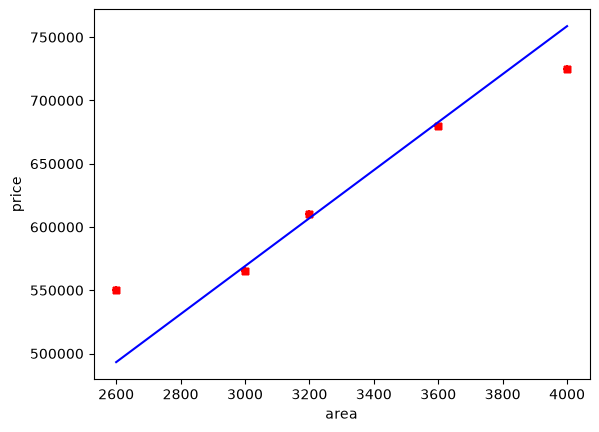

In [47]:
%matplotlib inline
def gradient_decent1(x,y):
    m_curr = b_curr = 0
    iterations = 10000
    n = len(x)
    learning_rate = 0.00000001
    plt.scatter(x,y,color= 'red',marker = '+',linewidths=5)
    
    for i in range(iterations):
        y_predicted = m_curr*x + b_curr
        cost = (1/n)*sum([val**2 for val in (y-y_predicted)])
        md = -(2/n)*sum(x*(y-y_predicted))
        bd = -(2/n)*sum(y-y_predicted)
        m_curr = m_curr - learning_rate * md
        b_curr = b_curr - learning_rate * bd

    %matplotlib inline
    plt.xlabel('area')
    plt.ylabel('price')
    plt.scatter(df.area,df.price, color='red',marker = '+')
    plt.plot(x,y_predicted,color='blue')

    plt.show()

gradient_decent1(df.area,df.price)

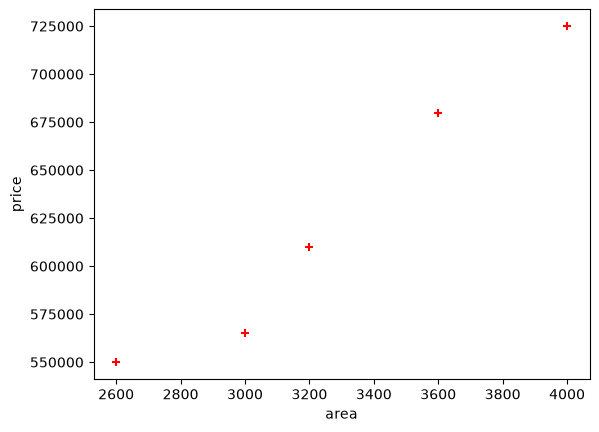

In [25]:
%matplotlib inline
plt.xlabel('area')
plt.ylabel('price')
plt.scatter(df.area,df.price, color='red',marker = '+')

In [26]:
reg = linear_model.LinearRegression()
reg.fit(df[['area']],df.price)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[135.79]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['area']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.806e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [27]:
reg.predict([[3300]])

c:\ai_ml_learning\ml\linear_regression\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([628715.75342466])

In [28]:
reg.coef_

array([135.78767123])

In [29]:
reg.intercept_

np.float64(180616.43835616432)

In [30]:
ar = pd.read_csv("areas.csv")
ar


,area
0,1000
1,1500
2,2300
3,3540
4,4120
5,4560
6,5490
7,7100
8,8400
9,9000


In [31]:
ar.head(3)

,area
0,1000
1,1500
2,2300


In [32]:
p = reg.predict(ar)
p

array([ 316404.10958904,  384297.94520548,  492928.08219178,
        661304.79452055,  740061.64383562,  799808.21917808,
        926090.75342466, 1144708.90410959, 1321232.87671233,
       1402705.47945205])

In [33]:
ar['price'] = p

In [34]:
ar

,area,price
0,1000,3.164041e+05
1,1500,3.842979e+05
2,2300,4.929281e+05
3,3540,6.613048e+05
4,4120,7.400616e+05
5,4560,7.998082e+05
6,5490,9.260908e+05
7,7100,1.144709e+06
8,8400,1.321233e+06
9,9000,1.402705e+06


In [35]:
ar.to_csv("homePrediction.csv")

# Save model using pickle

In [36]:
import pickle

In [37]:
with open("model_pickle",'wb') as f:
    pickle.dump(reg,f)

using saved model by pickle

In [38]:
with open('model_pickle','rb') as f:
    mp = pickle.load(f)

In [39]:
mp.predict([[5000]])

c:\ai_ml_learning\ml\linear_regression\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([859554.79452055])

# Saving model using joblib

for large dataset

In [40]:
import joblib

In [41]:
joblib.dump(reg,'model_joblib')

['model_joblib']

using saved model by joblib

In [42]:
mj = joblib.load('model_joblib')


In [43]:
mj.predict([[5000]])

c:\ai_ml_learning\ml\linear_regression\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([859554.79452055])